#  Portafolio de Inversiones — Modelos Cuantitativos
## Análisis de Mercados Financieros

**Alumno:** Mauricio Martínez García
**Materia:** Econometría Financiera
**Profesor:** Raymundo Díaz
**Fecha:** 20 de Marzo 2026

---

##  Descripción del Proyecto

Análisis cuantitativo de un portafolio de 10 acciones usando datos intraday
de **Refinitiv Eikon** (frecuencia: 1 minuto) ejecutado en Google Colab.

### Acciones del Portafolio (HowMarketsWorks)
| Ticker | Empresa | Sector |
|--------|---------|--------|
| HD | Home Depot | Consumer |
| BAC | Bank of America | Financials |
| AMZN | Amazon | Technology |
| AAPL | Apple | Technology |
| CAT | Caterpillar | Industrials |
| XLE | Energy Select SPDR | Energy |
| META | Meta Platforms | Technology |
| TQQQ | ProShares UltraPro QQQ | ETF 3x |
| NVDA | NVIDIA | Technology |
| SOXL | Direxion Semiconductors | ETF 3x |

### Fuente de Datos
- **Refinitiv Eikon/Workspace** — datos intraday 1 minuto
- **Período:** 11 Mar 2026 — 16 Mar 2026
- **Frecuencia:** 1 minuto por acción

In [22]:
!pip install openpyxl statsmodels scikit-learn plotly arch -q

In [23]:
for t in tickers_ok:
    print(f"{t}: {len(data[t])} filas | {data[t].index[0]} → {data[t].index[-1]}")

print("\n--- Cruces de datos ---")
for t in tickers_ok:
    comun = returns[[t for t in tickers_ok]].dropna()
print(f"Filas comunes a todos: {len(comun)}")

for t1 in tickers_ok:
    for t2 in tickers_ok:
        if t1 < t2:
            n = returns[[t1,t2]].dropna().shape[0]
            print(f"{t1} vs {t2}: {n} filas comunes")

HD: 1163 filas | 2026-03-12 07:30:59.999996416 → 2026-03-16 13:54:00.000003072
BAC: 2330 filas | 2026-03-11 14:01:59.999997952 → 2026-03-16 14:05:00.000003584
AMZN: 2842 filas | 2026-03-11 14:01:59.999997952 → 2026-03-16 14:08:59.999996928
AAPL: 2794 filas | 2026-03-11 14:01:59.999997952 → 2026-03-16 13:59:59.999996416
CAT: 2049 filas | 2026-03-11 14:01:59.999997952 → 2026-03-16 14:08:59.999996928
XLE: 1201 filas | 2026-03-12 05:46:59.999997952 → 2026-03-16 13:59:59.999996416
META: 2840 filas | 2026-03-11 14:01:59.999997952 → 2026-03-16 14:08:59.999996928
TQQQ: 1375 filas | 2026-03-12 05:03:59.999998976 → 2026-03-16 13:59:59.999996416
NVDA: 2888 filas | 2026-03-11 14:01:59.999997952 → 2026-03-16 14:08:59.999996928
SOXL: 720 filas | 2026-03-11 19:25:59.999997440 → 2026-03-16 01:00:59.999998976

--- Cruces de datos ---
Filas comunes a todos: 0
HD vs XLE: 0 filas comunes
HD vs META: 0 filas comunes
HD vs TQQQ: 0 filas comunes
HD vs NVDA: 0 filas comunes
HD vs SOXL: 0 filas comunes
BAC vs 

In [24]:
# SOLUCIÓN: redondear timestamps al minuto
for t in tickers_ok:
    data[t].index = data[t].index.round('min')

# Reconstruir prices y returns con índices alineados
prices = pd.concat(
    [data[t]['Close'].rename(t) for t in tickers_ok], axis=1
).sort_index()

returns = np.log(prices / prices.shift(1)).dropna()

# Verificar
print(f"Filas en prices: {len(prices)}")
print(f"Filas en returns: {len(returns)}")
print(f"\nDatos por ticker (no-NaN):")
for t in tickers_ok:
    print(f"  {t}: {prices[t].notna().sum()} filas")

print(f"\nFilas comunes a todos: {prices.dropna().shape[0]}")

# Verificar un par
test = returns[['AMZN','NVDA']].dropna()
print(f"\nAMZN vs NVDA filas comunes: {len(test)}")

Filas en prices: 3608
Filas en returns: 0

Datos por ticker (no-NaN):
  HD: 1163 filas
  BAC: 2330 filas
  AMZN: 2842 filas
  AAPL: 2794 filas
  CAT: 2049 filas
  XLE: 1201 filas
  META: 2840 filas
  TQQQ: 1375 filas
  NVDA: 2888 filas
  SOXL: 720 filas

Filas comunes a todos: 0

AMZN vs NVDA filas comunes: 0


In [25]:
# Diagnóstico profundo
print("=== Muestra de índices por ticker ===")
for t in tickers_ok:
    idx = data[t].index
    print(f"\n{t} — primeros 3 timestamps:")
    for i in idx[:3]:
        print(f"  {i}  |  tipo: {type(i)}  |  repr: {repr(i)}")

print("\n=== Solapamiento AMZN vs NVDA ===")
idx_amzn = set(data['AMZN'].index)
idx_nvda = set(data['NVDA'].index)
comun = idx_amzn & idx_nvda
print(f"Timestamps en común: {len(comun)}")
if len(comun) > 0:
    print("Ejemplo:", list(comun)[:3])
else:
    # Ver si son casi iguales
    a1 = sorted(data['AMZN'].index)[:5]
    n1 = sorted(data['NVDA'].index)[:5]
    print("AMZN primeros 5:", a1)
    print("NVDA primeros 5:", n1)
    print("\nDiferencia en nanosegundos:")
    for a, n in zip(a1, n1):
        print(f"  {int((a-n).total_seconds()*1e9)} ns")

=== Muestra de índices por ticker ===

HD — primeros 3 timestamps:
  2026-03-12 07:31:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-12 07:31:00')
  2026-03-12 07:32:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-12 07:32:00')
  2026-03-12 07:33:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-12 07:33:00')

BAC — primeros 3 timestamps:
  2026-03-11 14:02:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-11 14:02:00')
  2026-03-11 14:03:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-11 14:03:00')
  2026-03-11 14:04:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-11 14:04:00')

AMZN — primeros 3 timestamps:
  2026-03-11 14:02:00  |  tipo: <class 'pandas._libs.tslibs.timestamps.Timestamp'>  |  repr: Timestamp('2026-03-11 1

In [26]:
# RECONSTRUIR prices y returns correctamente
# El problema es que pd.concat con axis=1 expande en lugar de alinear
# cuando hay índices duplicados. Usamos un join explícito.

# Paso 1: eliminar duplicados en cada serie primero
for t in tickers_ok:
    if data[t].index.duplicated().any():
        print(f"⚠️  {t} tiene {data[t].index.duplicated().sum()} duplicados — eliminando")
        data[t] = data[t][~data[t].index.duplicated(keep='first')]

# Paso 2: reconstruir con join en lugar de concat
prices = data[tickers_ok[0]]['Close'].rename(tickers_ok[0]).to_frame()
for t in tickers_ok[1:]:
    prices = prices.join(data[t]['Close'].rename(t), how='outer')
prices = prices.sort_index()

# Paso 3: retornos solo donde hay precio (cada ticker independiente)
returns = np.log(prices / prices.shift(1))
# Quitar la primera fila (NaN por el shift)
returns = returns.iloc[1:]

# Verificar
print(f"prices shape: {prices.shape}")
print(f"returns shape: {returns.shape}")
print(f"\nNo-NaN por ticker en returns:")
for t in tickers_ok:
    print(f"  {t}: {returns[t].notna().sum():,} filas")

print(f"\nPrueba AMZN vs NVDA:")
test = returns[['AMZN','NVDA']].dropna()
print(f"  Filas comunes: {len(test)}")
print(f"  Primeras 3 filas:")
print(test.head(3))

prices shape: (3608, 10)
returns shape: (3607, 10)

No-NaN por ticker en returns:
  HD: 1,157 filas
  BAC: 2,034 filas
  AMZN: 2,794 filas
  AAPL: 2,722 filas
  CAT: 1,705 filas
  XLE: 1,172 filas
  META: 2,791 filas
  TQQQ: 1,277 filas
  NVDA: 2,884 filas
  SOXL: 717 filas

Prueba AMZN vs NVDA:
  Filas comunes: 2794
  Primeras 3 filas:
                             AMZN      NVDA
DateTime                                   
2026-03-11 14:03:00  1.883505e-04 -0.000269
2026-03-11 14:04:00  4.802371e-05 -0.000108
2026-03-11 14:05:00 -9.416191e-07 -0.000754


---
## Modelo 1: Regresión Lineal Simple

**Objetivo:** Determinar si los retornos de NVDA son un predictor
significativo de los retornos de AMZN en frecuencia de 1 minuto.

**Hipótesis:**
- H₀: β₁ = 0 (NVDA no explica AMZN)
- H₁: β₁ ≠ 0 (NVDA sí explica AMZN)

**Modelo:** Retorno(AMZN)ₜ = β₀ + β₁·Retorno(NVDA)ₜ + εₜ

---
##  Modelo 2: Regresión Lineal Múltiple

**Objetivo:** Modelo de factores para AAPL usando sus principales
correlaciones del portafolio.

**Modelo:** Retorno(AAPL)ₜ = β₀ + β₁·AMZN + β₂·NVDA + β₃·META + β₄·XLE + εₜ

**Diagnósticos incluidos:**
- R² y R² ajustado
- VIF (Factor de Inflación de Varianza) para detectar multicolinealidad
- Q-Q Plot de residuales

---
##  Modelo 3: Data Panel

**Objetivo:** Analizar el comportamiento de retornos por hora del día
para todas las empresas simultáneamente.

**Modelos estimados:**
1. **Pooled OLS** — coeficientes homogéneos entre empresas
2. **Panel OLS con Efectos Fijos** — controla heterogeneidad por empresa

**Variable dependiente:** Retorno horario acumulado
**Variable independiente:** Volatilidad horaria

---
##  Modelo 4: Series de Tiempo + Forecast SARIMA

**Objetivo:** Pronosticar el precio de NVDA, AAPL y AMZN
para las próximas 24-48 horas hábiles.

**Proceso:**
1. Test ADF — verificar estacionariedad
2. Descomposición STL — Tendencia + Estacionalidad + Residuo
3. ACF/PACF — identificar órdenes AR y MA
4. SARIMA(1,d,1)(1,0,1,7) — modelo final
5. Forecast con Intervalo de Confianza 90%

**Datos:** Precios horarios (resampleados desde 1-min)

---
##  Modelo Extra: GARCH(1,1) — Puntos Extra

**Objetivo:** Modelar la volatilidad condicional de los activos
más volátiles del portafolio.

**Modelo:** σ²ₜ = ω + α·ε²ₜ₋₁ + β·σ²ₜ₋₁

**Interpretación de parámetros:**
- **α (alpha):** reacción de la volatilidad a shocks recientes
- **β (beta):** persistencia de la volatilidad
- **α + β:** si cercano a 1 = alta persistencia (shocks tardan en disiparse)

**Activos analizados:** NVDA, SOXL, TQQQ, AAPL

📊 ESTADÍSTICAS DESCRIPTIVAS (Refinitiv 1-min)
Ticker   Obs  Precio_Min  Precio_Max  Último  Vol_1min_%  Vol_Diaria_%  Vol_Anual_%
    HD 1,157      338.17      348.16  342.94     0.06712          1.33         21.0
   BAC 2,034       46.59       48.54   47.06     0.09956          1.97         31.2
  AMZN 2,794      198.94      218.72  211.77     0.21097          4.17         66.1
  AAPL 2,722      245.48      260.94  252.78     0.19240          3.80         60.3
   CAT 1,705      680.16      709.87  700.21     0.12701          2.51         39.8
   XLE 1,172       57.09       58.20   57.90     0.06239          1.23         19.6
  META 2,791      577.34      654.50  627.31     0.26632          5.26         83.5
  TQQQ 1,277       45.69       49.00   47.47     0.15332          3.03         48.1
  NVDA 2,884      175.80      190.84  183.42     0.18089          3.57         56.7
  SOXL   717        5.45        6.08    5.66     0.26536          5.24         83.2


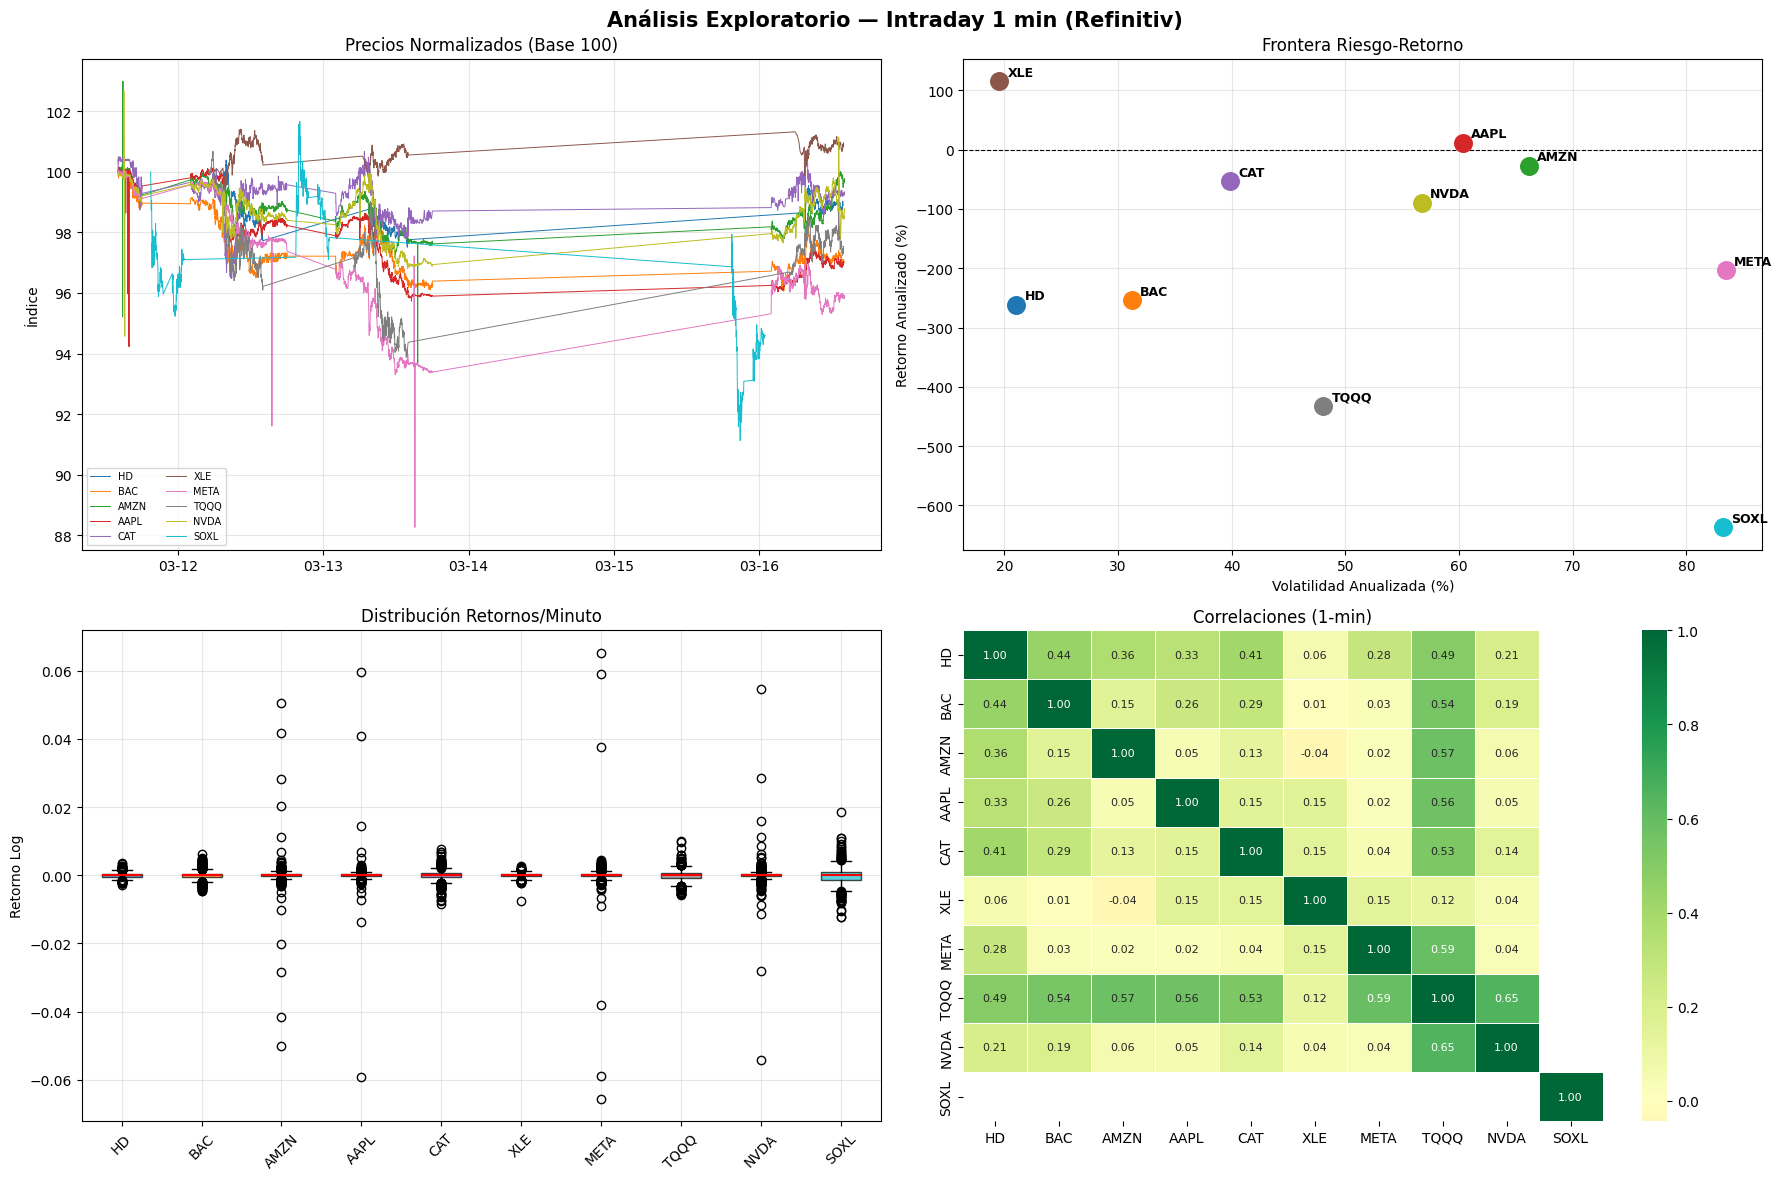

✅ 01_EDA_intraday.png

📐 MODELO 1: REGRESIÓN LINEAL SIMPLE
Dep: AMZN | Ind: NVDA | N=2,794
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     10.33
Date:                Mon, 16 Mar 2026   Prob (F-statistic):            0.00132
Time:                        23:50:51   Log-Likelihood:                 13256.
No. Observations:                2794   AIC:                        -2.651e+04
Df Residuals:                    2792   BIC:                        -2.650e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

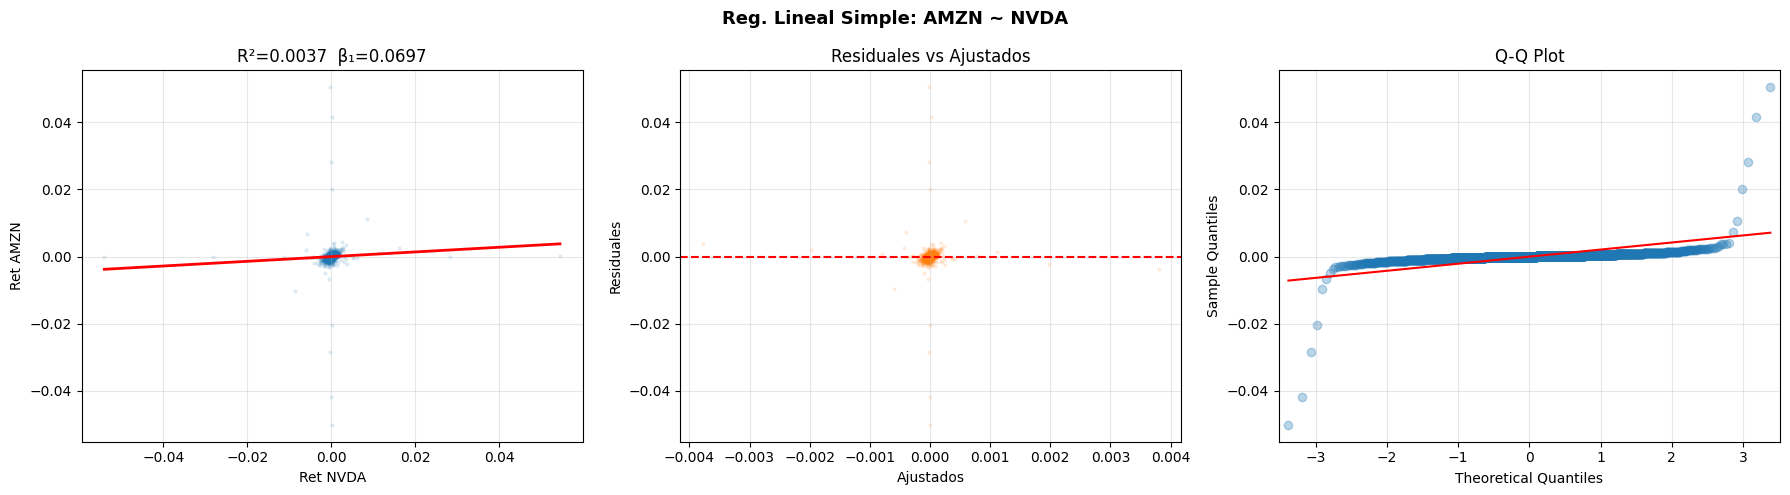

✅ 02_reg_simple.png

📐 MODELO 2: REGRESIÓN LINEAL MÚLTIPLE
Fórmula: AAPL ~ AMZN + NVDA + META + XLE | N=1,171
                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     143.9
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          5.10e-100
Time:                        23:50:53   Log-Likelihood:                 7217.9
No. Observations:                1171   AIC:                        -1.443e+04
Df Residuals:                    1166   BIC:                        -1.440e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

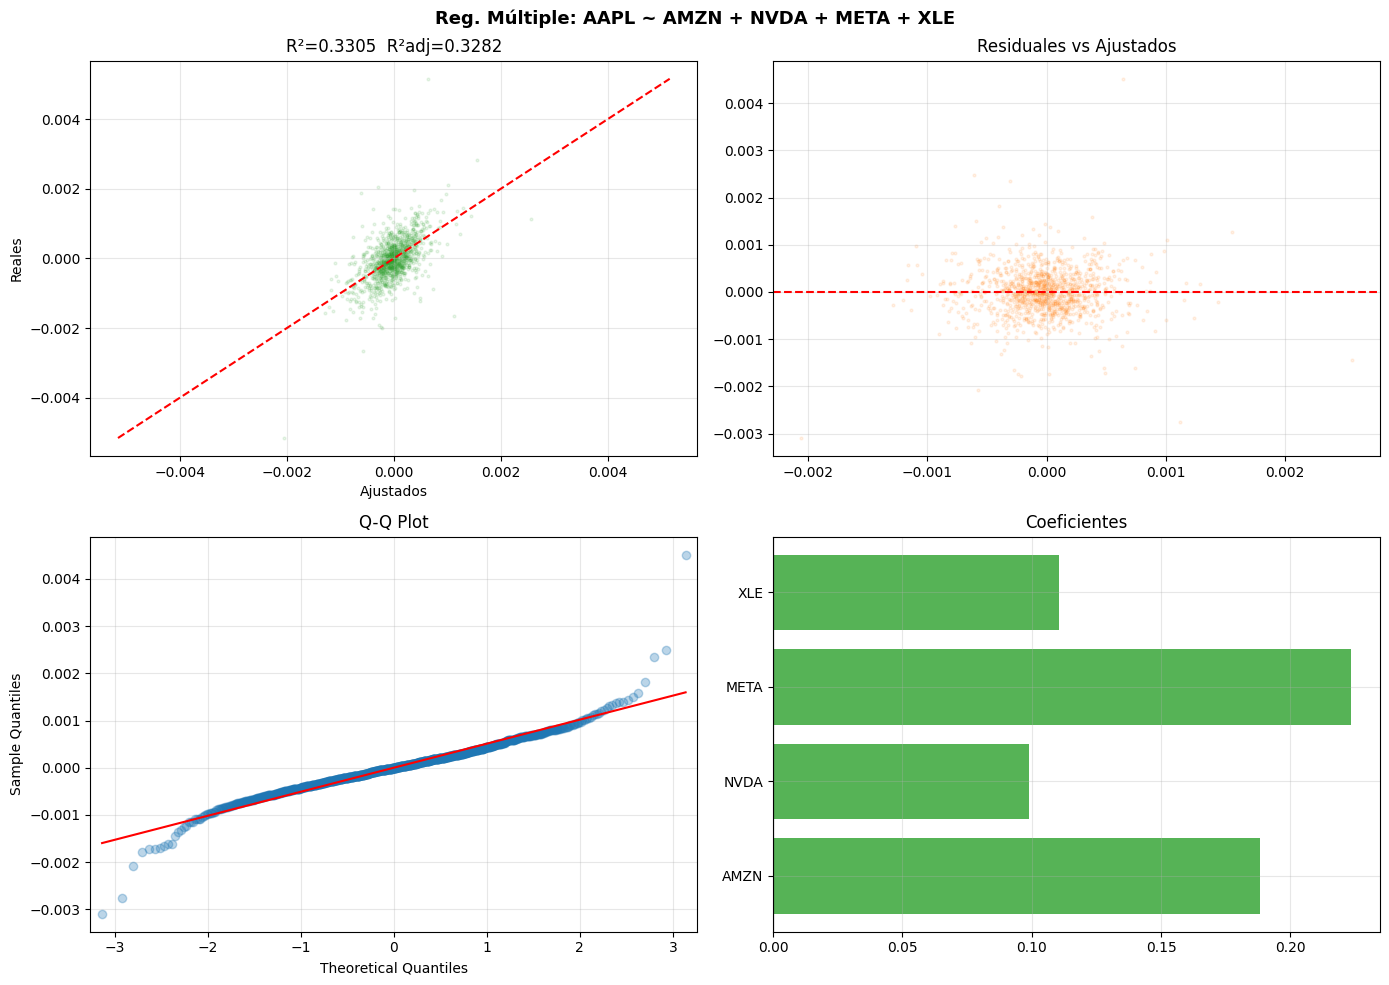

✅ 03_reg_multiple.png

📊 MODELO 3: DATA PANEL — Retornos por Hora
Panel: 383 obs | 10 empresas

Pooled OLS — Ret ~ Vol
  β₀=-0.000532  β₁=-0.009030  R²=0.0000  p=0.9654

Panel FE (dummies empresa)
  R²=0.0145  R²adj=-0.0120  N=383


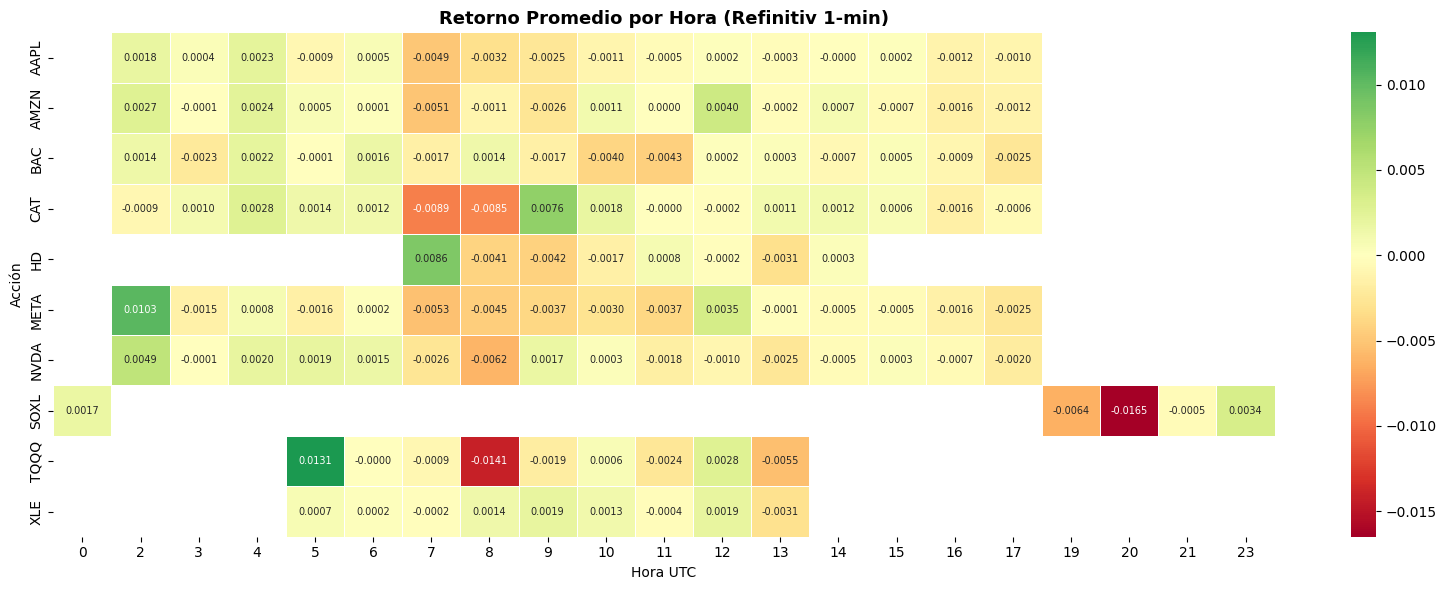

✅ 04_panel_hora.png

📈 MODELO 4: SARIMA — Forecast 24h

  ▶ NVDA...
    d=1
    ✅ $183.42 → $183.48 (+0.0%)

  ▶ AAPL...
    d=1
    ✅ $252.78 → $252.67 (-0.0%)

  ▶ AMZN...
    d=1
    ✅ $211.77 → $213.36 (+0.8%)


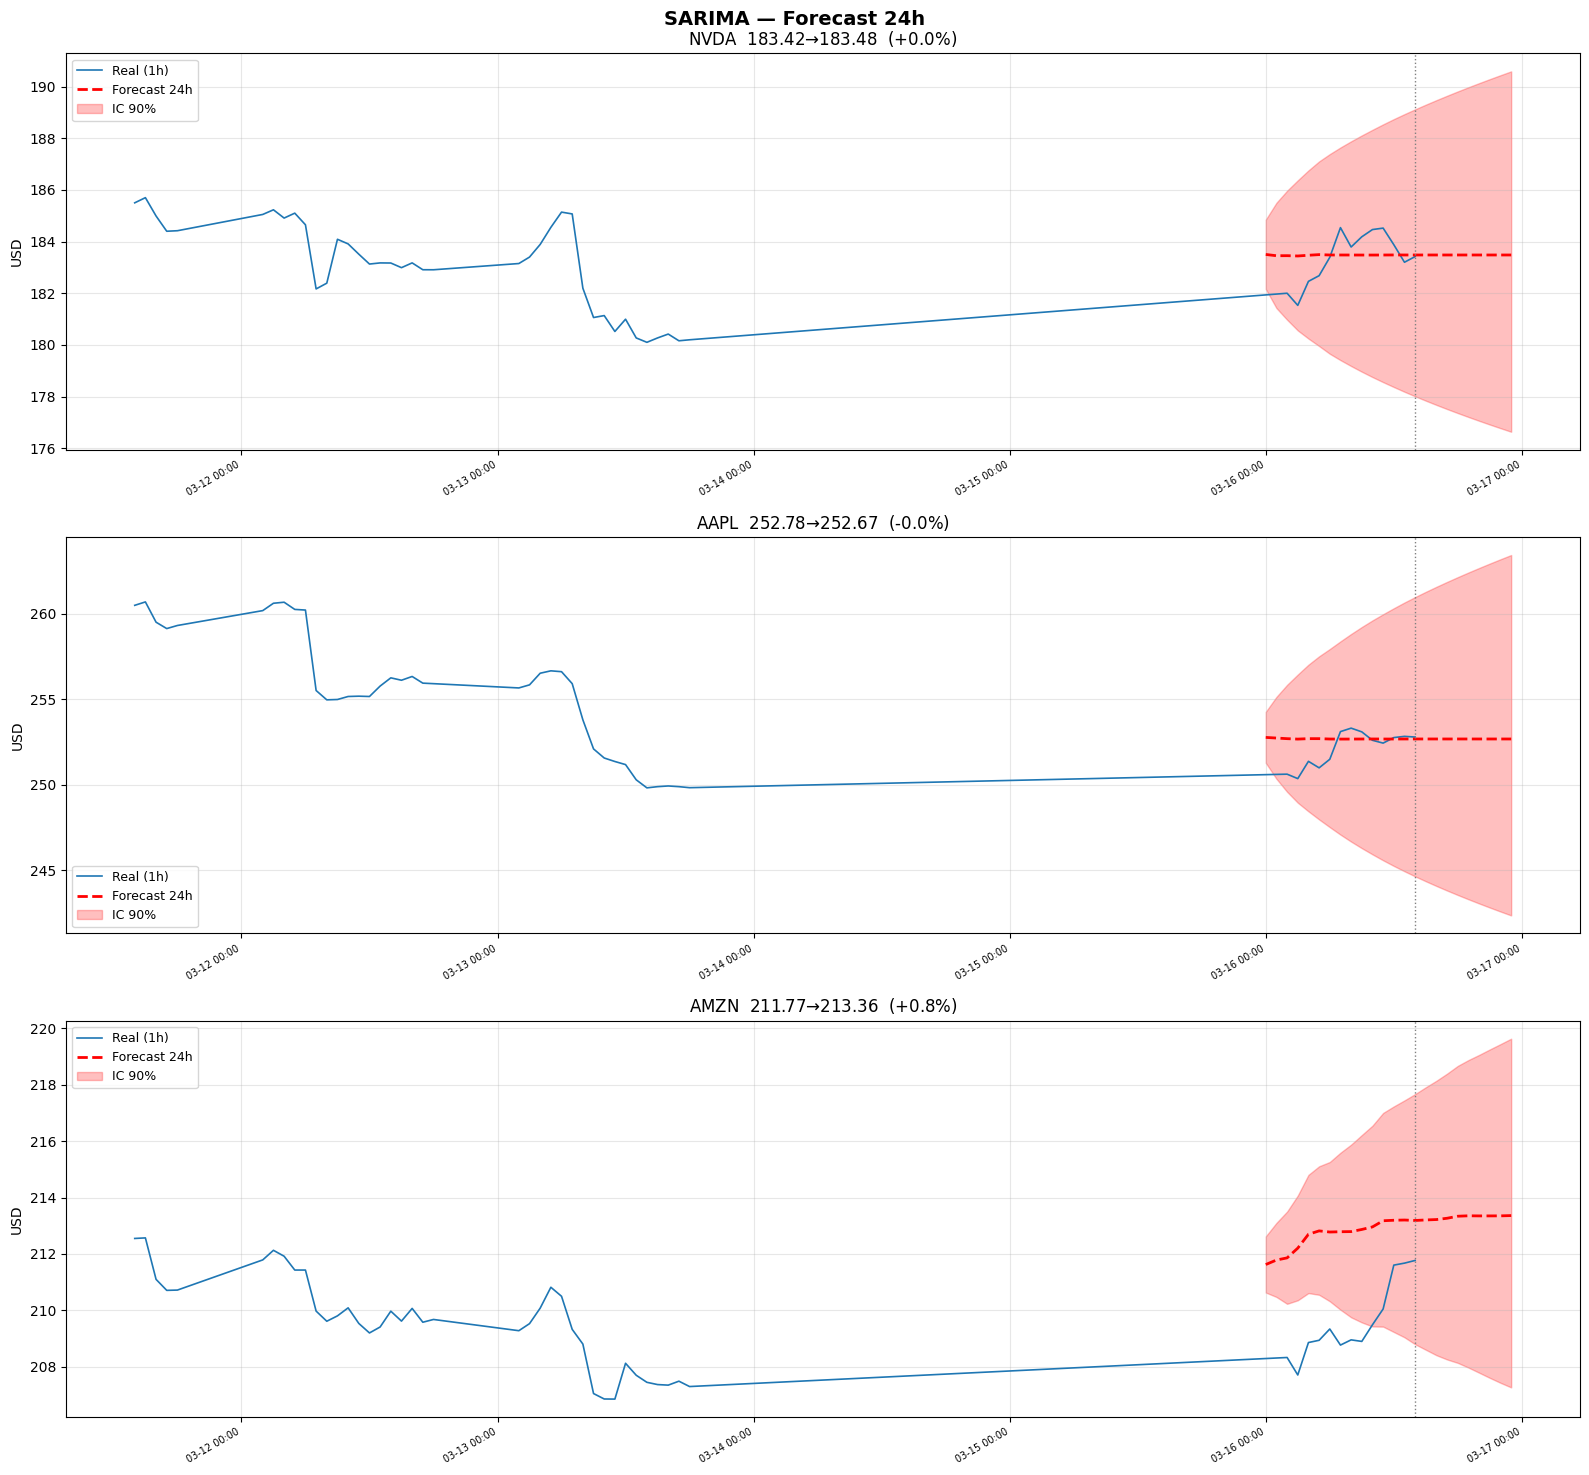

✅ 05_sarima_forecast.png


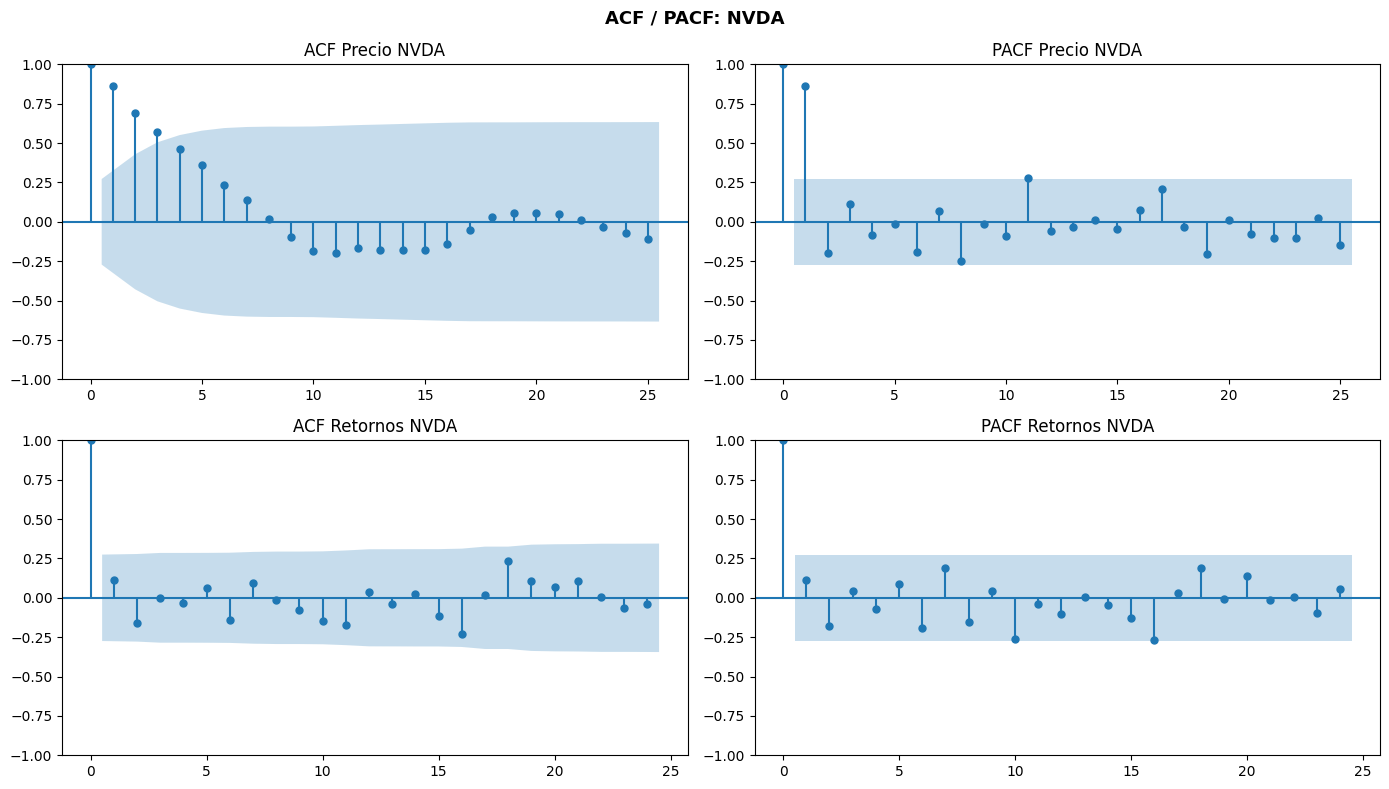

✅ 06_acf_pacf.png


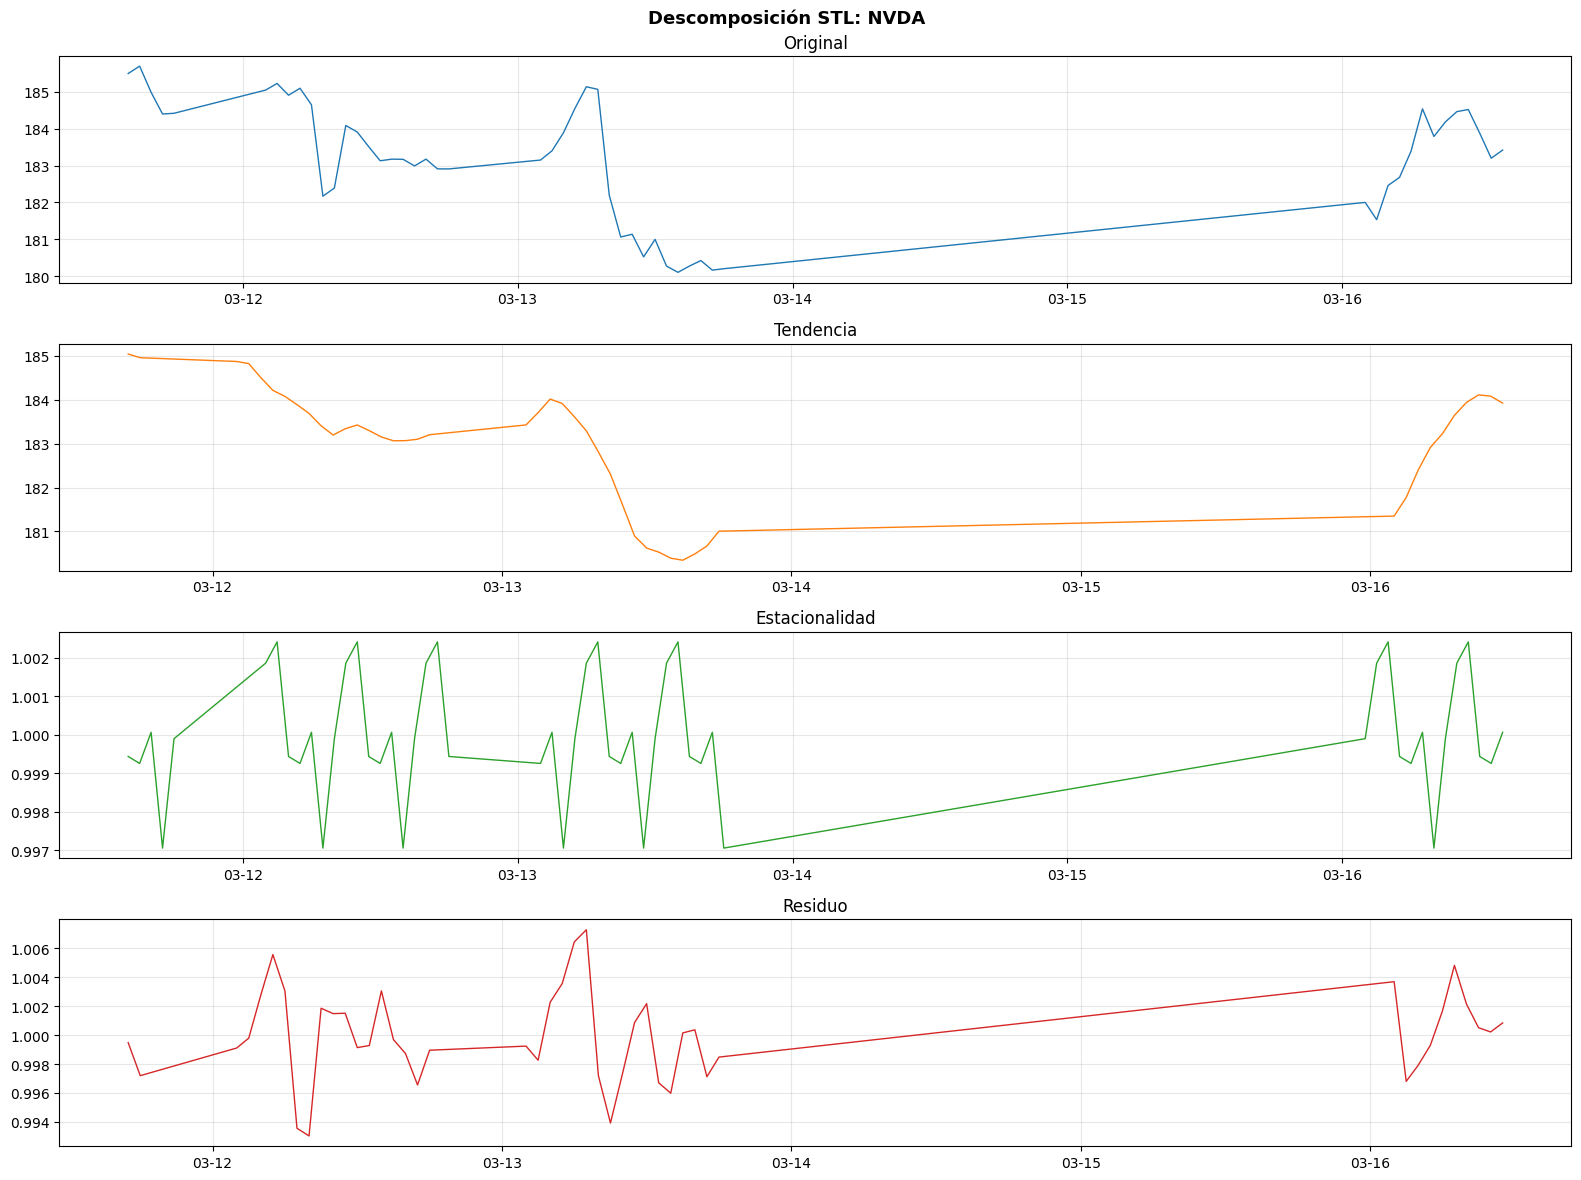

✅ 07_descomposicion.png

⭐ GARCH(1,1) — Volatilidad Condicional


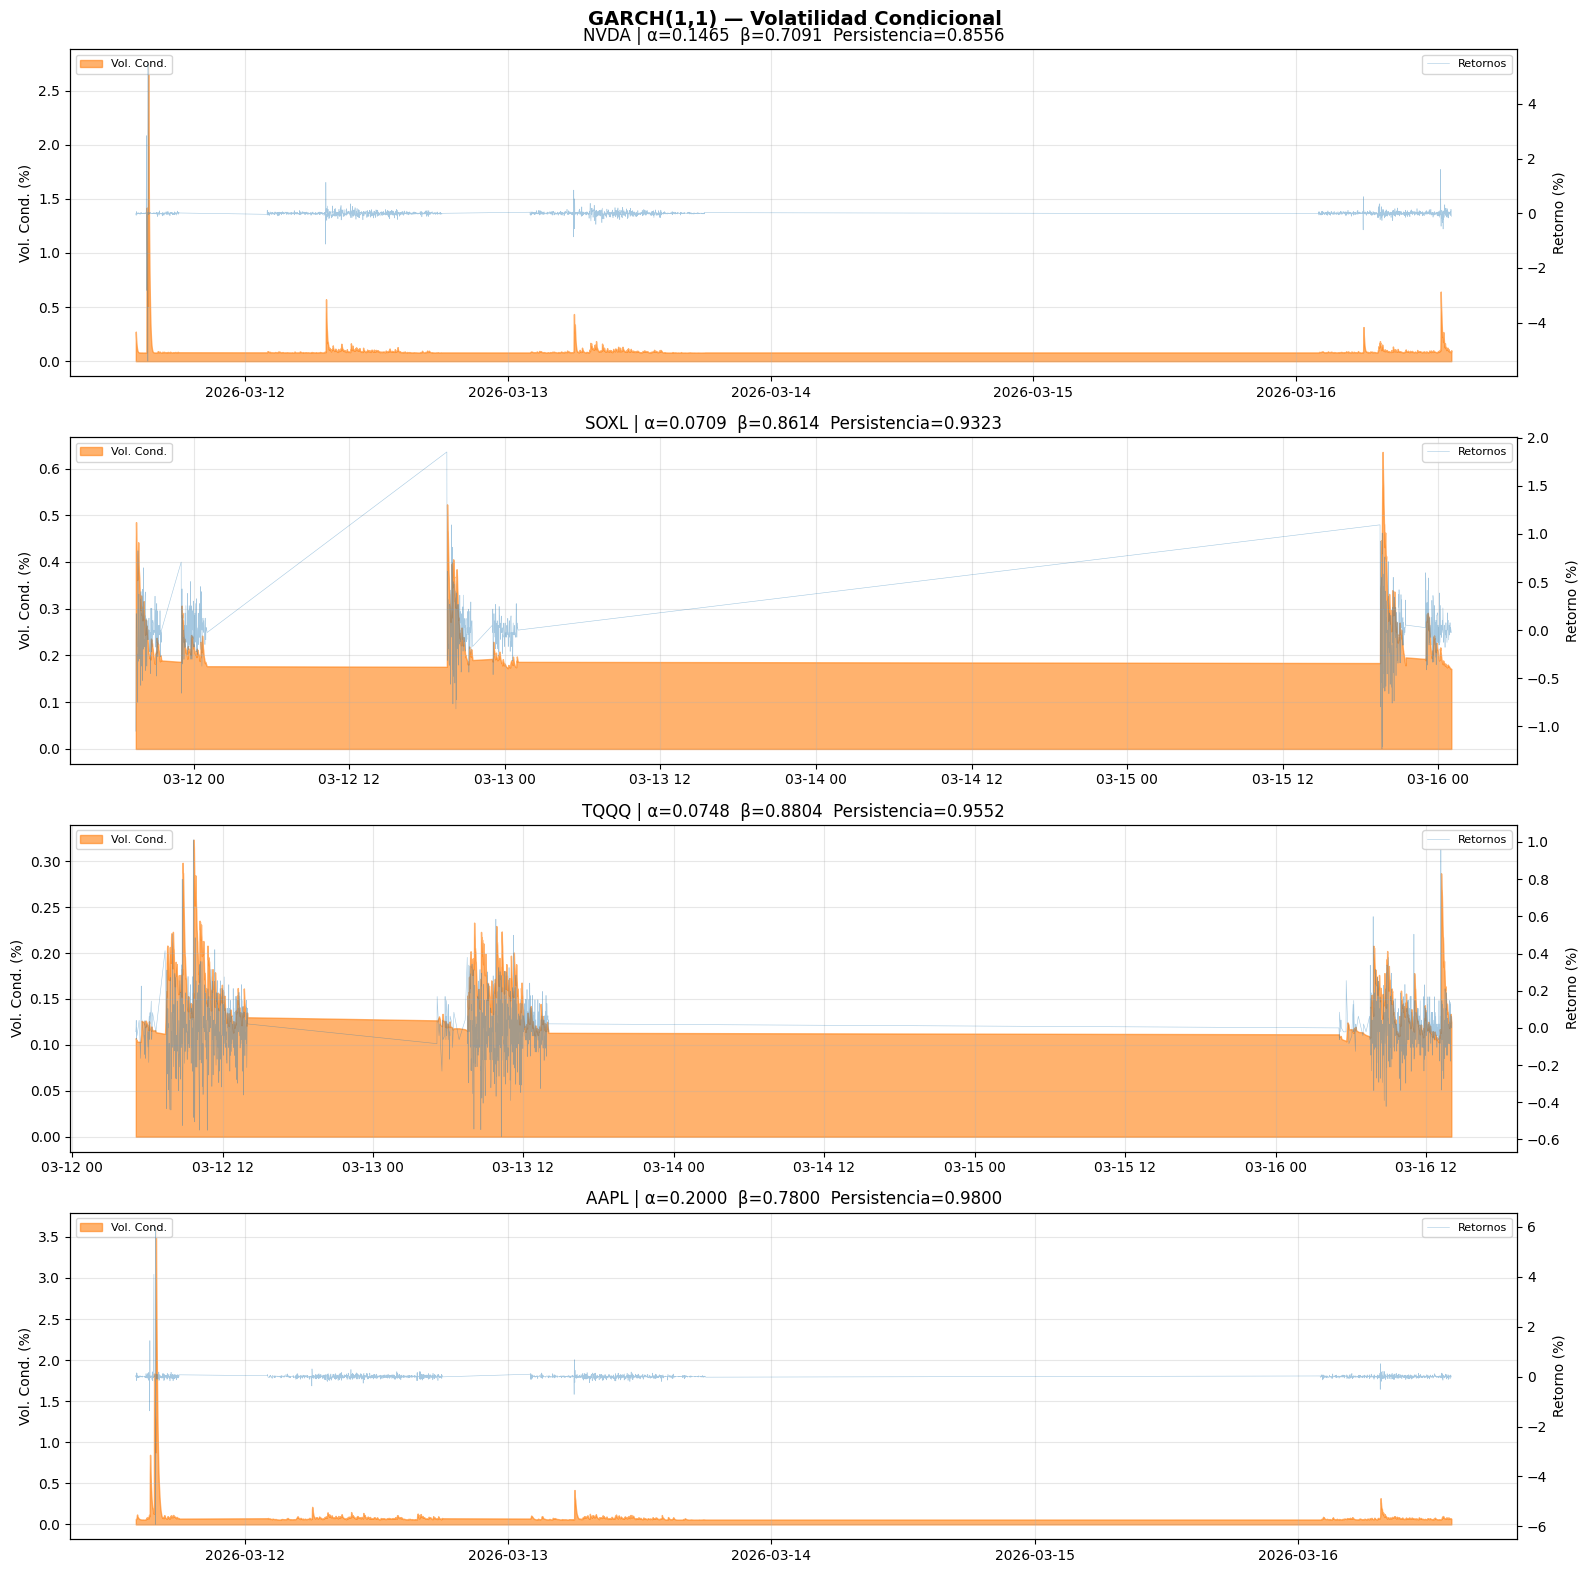

✅ 08_garch.png

  Ticker        α        β        α+β
  ----------------------------------
  NVDA     0.1465   0.7091     0.8556
  SOXL     0.0709   0.8614     0.9323
  TQQQ     0.0748   0.8804     0.9552
  AAPL     0.2000   0.7800     0.9800

🌐 Generando dashboard HTML...
✅ dashboard_intraday.html

✅ PROYECTO COMPLETO
  📄 01_EDA_intraday.png                 → EDA exploratoria
  📄 02_reg_simple.png                   → Regresión Lineal Simple
  📄 03_reg_multiple.png                 → Regresión Múltiple + VIF
  📄 04_panel_hora.png                   → Data Panel por hora
  📄 05_sarima_forecast.png              → SARIMA Forecast 24h
  📄 06_acf_pacf.png                     → ACF/PACF
  📄 07_descomposicion.png               → Descomposición STL
  📄 08_garch.png                        → ⭐ GARCH(1,1)
  📄 dashboard_intraday.html             → 🌐 Dashboard Plotly


In [27]:
# ══════════════════════════════════════════════════════
# MODELOS — usar este bloque completo desde aquí
# ══════════════════════════════════════════════════════

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

# ── ESTADÍSTICAS ──────────────────────────────────────
print("="*60)
print("📊 ESTADÍSTICAS DESCRIPTIVAS (Refinitiv 1-min)")
print("="*60)
rows_stats = []
for t in tickers_ok:
    r = returns[t].dropna()
    p = prices[t].dropna()
    rows_stats.append({
        'Ticker':       t,
        'Obs':          f"{len(r):,}",
        'Precio_Min':   round(p.min(), 2),
        'Precio_Max':   round(p.max(), 2),
        'Último':       round(p.iloc[-1], 2),
        'Vol_1min_%':   round(r.std()*100, 5),
        'Vol_Diaria_%': round(r.std()*np.sqrt(390)*100, 2),
        'Vol_Anual_%':  round(r.std()*np.sqrt(390*252)*100, 1),
    })
print(pd.DataFrame(rows_stats).to_string(index=False))

# ── EDA ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis Exploratorio — Intraday 1 min (Refinitiv)',
             fontsize=15, fontweight='bold')

ax = axes[0,0]
for i, t in enumerate(tickers_ok):
    p = prices[t].dropna()
    ax.plot(p.index, p/p.iloc[0]*100, label=t,
            color=COLORS[i%10], linewidth=0.7)
ax.set_title('Precios Normalizados (Base 100)')
ax.set_ylabel('Índice'); ax.legend(ncol=2, fontsize=7); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax = axes[0,1]
vol_ann = returns.std() * np.sqrt(390*252) * 100
ret_ann = returns.mean() * 390 * 252 * 100
for i, t in enumerate(tickers_ok):
    ax.scatter(vol_ann[t], ret_ann[t], s=160, color=COLORS[i%10], zorder=5)
    ax.annotate(t, (vol_ann[t], ret_ann[t]),
                textcoords="offset points", xytext=(6,4),
                fontsize=9, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Volatilidad Anualizada (%)')
ax.set_ylabel('Retorno Anualizado (%)')
ax.set_title('Frontera Riesgo-Retorno'); ax.grid(alpha=0.3)

ax = axes[1,0]
bp = ax.boxplot([returns[t].dropna().values for t in tickers_ok],
                labels=tickers_ok, patch_artist=True,
                medianprops=dict(color='red', linewidth=1.5))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Distribución Retornos/Minuto')
ax.set_ylabel('Retorno Log')
ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.3)

ax = axes[1,1]
corr = returns[tickers_ok].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, annot_kws={'size':8}, linewidths=0.5)
ax.set_title('Correlaciones (1-min)')

plt.tight_layout()
plt.savefig('01_EDA_intraday.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 01_EDA_intraday.png")

# ── REGRESIÓN SIMPLE ──────────────────────────────────
print("\n" + "="*60)
print("📐 MODELO 1: REGRESIÓN LINEAL SIMPLE")
print("="*60)

t_dep, t_ind = 'AMZN', 'NVDA'
df_rl = returns[[t_dep, t_ind]].dropna()
y_rl  = df_rl[t_dep].values
x_rl  = df_rl[t_ind].values
X_rl  = add_constant(x_rl)
m_rl  = OLS(y_rl, X_rl).fit()

print(f"Dep: {t_dep} | Ind: {t_ind} | N={len(df_rl):,}")
print(m_rl.summary())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Reg. Lineal Simple: {t_dep} ~ {t_ind}', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(x_rl, y_rl, alpha=0.1, color='#1f77b4', s=4)
xs = np.linspace(x_rl.min(), x_rl.max(), 200)
ax.plot(xs, m_rl.params[0] + m_rl.params[1]*xs, color='red', linewidth=2)
ax.set_xlabel(f'Ret {t_ind}'); ax.set_ylabel(f'Ret {t_dep}')
ax.set_title(f'R²={m_rl.rsquared:.4f}  β₁={m_rl.params[1]:.4f}')
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(m_rl.fittedvalues, m_rl.resid, alpha=0.1, color='#ff7f0e', s=4)
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Ajustados'); ax.set_ylabel('Residuales')
ax.set_title('Residuales vs Ajustados'); ax.grid(alpha=0.3)

ax = axes[2]
sm.qqplot(m_rl.resid, line='s', ax=ax, alpha=0.3)
ax.set_title('Q-Q Plot'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_reg_simple.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 02_reg_simple.png")

# ── REGRESIÓN MÚLTIPLE ────────────────────────────────
print("\n" + "="*60)
print("📐 MODELO 2: REGRESIÓN LINEAL MÚLTIPLE")
print("="*60)

t_y    = 'AAPL'
vars_x = [t for t in ['AMZN','NVDA','META','XLE'] if t in tickers_ok]
df_m   = returns[[t_y] + vars_x].dropna()
m_mul  = smf.ols(f"{t_y} ~ {' + '.join(vars_x)}", data=df_m).fit()

print(f"Fórmula: {t_y} ~ {' + '.join(vars_x)} | N={len(df_m):,}")
print(m_mul.summary())

X_vif  = add_constant(df_m[vars_x])
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})
print("\nVIF:"); print(vif_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Reg. Múltiple: {t_y} ~ {" + ".join(vars_x)}',
             fontsize=13, fontweight='bold')

y_fit = m_mul.fittedvalues; res_m = m_mul.resid

ax = axes[0,0]
ax.scatter(y_fit, df_m[t_y], alpha=0.1, color='#2ca02c', s=4)
lims = [min(y_fit.min(), df_m[t_y].min()), max(y_fit.max(), df_m[t_y].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5)
ax.set_title(f'R²={m_mul.rsquared:.4f}  R²adj={m_mul.rsquared_adj:.4f}')
ax.set_xlabel('Ajustados'); ax.set_ylabel('Reales'); ax.grid(alpha=0.3)

ax = axes[0,1]
ax.scatter(y_fit, res_m, alpha=0.1, color='#ff7f0e', s=4)
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_title('Residuales vs Ajustados'); ax.grid(alpha=0.3)

ax = axes[1,0]
sm.qqplot(res_m, line='s', ax=ax, alpha=0.3)
ax.set_title('Q-Q Plot'); ax.grid(alpha=0.3)

ax = axes[1,1]
coefs = m_mul.params[1:]
ax.barh(coefs.index, coefs.values,
        color=['#2ca02c' if c > 0 else '#d62728' for c in coefs], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_reg_multiple.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 03_reg_multiple.png")

# ── DATA PANEL ────────────────────────────────────────
print("\n" + "="*60)
print("📊 MODELO 3: DATA PANEL — Retornos por Hora")
print("="*60)

panel_rows = []
for t in tickers_ok:
    df_t = data[t][['Close','Volume']].copy()
    df_t['ret'] = np.log(df_t['Close'] / df_t['Close'].shift(1))
    hourly = df_t.resample('1h').agg(
        Close=('Close','last'),
        Volume=('Volume','sum'),
        Ret=('ret','sum'),
        Vol=('ret','std'),
        N=('ret','count'),
    ).dropna()
    hourly['Ticker'] = t
    hourly['Hora']   = hourly.index.hour
    panel_rows.append(hourly)

df_panel = pd.concat(panel_rows).reset_index()
print(f"Panel: {len(df_panel):,} obs | {df_panel['Ticker'].nunique()} empresas")

df_ols  = df_panel[['Ret','Vol','Ticker']].dropna()
X_pool  = add_constant(df_ols['Vol'].values)
m_pool  = OLS(df_ols['Ret'].values, X_pool).fit()
print(f"\nPooled OLS — Ret ~ Vol")
print(f"  β₀={m_pool.params[0]:.6f}  β₁={m_pool.params[1]:.6f}  "
      f"R²={m_pool.rsquared:.4f}  p={m_pool.pvalues[1]:.4f}")

df_fe = pd.get_dummies(df_ols, columns=['Ticker'], drop_first=True)
X_fe  = add_constant(df_fe.drop('Ret', axis=1).astype(float))
m_fe  = OLS(df_fe['Ret'].values, X_fe.values).fit()
print(f"\nPanel FE (dummies empresa)")
print(f"  R²={m_fe.rsquared:.4f}  R²adj={m_fe.rsquared_adj:.4f}  N={len(df_fe):,}")

pivot_h = df_panel.pivot_table(index='Ticker', columns='Hora',
                                values='Ret', aggfunc='mean')
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_h, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':7})
ax.set_title('Retorno Promedio por Hora (Refinitiv 1-min)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hora UTC'); ax.set_ylabel('Acción')
plt.tight_layout()
plt.savefig('04_panel_hora.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 04_panel_hora.png")

# ── SARIMA FORECAST ───────────────────────────────────
print("\n" + "="*60)
print("📈 MODELO 4: SARIMA — Forecast 24h")
print("="*60)

FORECAST_TICKERS = [t for t in ['NVDA','AAPL','AMZN'] if t in tickers_ok]
STEPS = 24

fig, axes = plt.subplots(len(FORECAST_TICKERS), 1,
                          figsize=(16, 5*len(FORECAST_TICKERS)))
if len(FORECAST_TICKERS) == 1: axes = [axes]
fig.suptitle(f'SARIMA — Forecast {STEPS}h', fontsize=14, fontweight='bold')

fc_results = {}
for idx, t in enumerate(FORECAST_TICKERS):
    print(f"\n  ▶ {t}...")
    s_h   = data[t]['Close'].resample('1h').last().dropna()
    log_s = np.log(s_h)
    d     = 0 if adfuller(log_s)[1] < 0.05 else 1
    print(f"    d={d}")
    try:
        res = SARIMAX(log_s, order=(1,d,1), seasonal_order=(1,0,1,7),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
        fc      = res.get_forecast(steps=STEPS)
        fc_mean = np.exp(fc.predicted_mean)
        fc_ci   = np.exp(fc.conf_int(alpha=0.10))
        fut_idx = pd.bdate_range(
            start=s_h.index[-1] + pd.Timedelta(hours=1),
            periods=STEPS, freq='h')
        fc_mean.index = fut_idx; fc_ci.index = fut_idx

        pa = float(data[t]['Close'].iloc[-1])
        pf = float(fc_mean.iloc[-1])
        fc_results[t] = {'actual': pa, 'forecast': pf}
        pct = (pf - pa) / pa * 100

        ax = axes[idx]
        hist = s_h.iloc[-150:]
        ax.plot(hist.index, hist.values, color='#1f77b4',
                linewidth=1.2, label='Real (1h)')
        ax.plot(fut_idx, fc_mean.values, color='red',
                linewidth=2, linestyle='--', label=f'Forecast {STEPS}h')
        ax.fill_between(fut_idx, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                        alpha=0.25, color='red', label='IC 90%')
        ax.axvline(s_h.index[-1], color='grey', linewidth=1, linestyle=':')
        ax.set_title(f'{t}  ${pa:.2f} → ${pf:.2f}  ({pct:+.1f}%)')
        ax.set_ylabel('USD'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        print(f"    ✅ ${pa:.2f} → ${pf:.2f} ({pct:+.1f}%)")
    except Exception as e:
        print(f"    ⚠️  {e}")

plt.tight_layout()
plt.savefig('05_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 05_sarima_forecast.png")

# ── ACF/PACF + DESCOMPOSICIÓN ─────────────────────────
t_d   = FORECAST_TICKERS[0]
s_h_d = data[t_d]['Close'].resample('1h').last().dropna()
ret_h = np.log(s_h_d / s_h_d.shift(1)).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'ACF / PACF: {t_d}', fontsize=13, fontweight='bold')
max_lags_precio  = min(40, len(s_h_d) // 2 - 1)
max_lags_retorno = min(40, len(ret_h)  // 2 - 1)

plot_acf( s_h_d, lags=max_lags_precio,  ax=axes[0,0], title=f'ACF Precio {t_d}')
plot_pacf(s_h_d, lags=max_lags_precio,  ax=axes[0,1], title=f'PACF Precio {t_d}')
plot_acf( ret_h, lags=max_lags_retorno, ax=axes[1,0], title=f'ACF Retornos {t_d}')
plot_pacf(ret_h, lags=max_lags_retorno, ax=axes[1,1], title=f'PACF Retornos {t_d}')
plt.tight_layout()
plt.savefig('06_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 06_acf_pacf.png")

decomp = seasonal_decompose(s_h_d, model='multiplicative', period=7)
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle(f'Descomposición STL: {t_d}', fontsize=13, fontweight='bold')
for ax, (title, comp, color) in zip(axes, [
    ('Original',       s_h_d,          '#1f77b4'),
    ('Tendencia',      decomp.trend,   '#ff7f0e'),
    ('Estacionalidad', decomp.seasonal,'#2ca02c'),
    ('Residuo',        decomp.resid,   '#d62728')]):
    ax.plot(comp.index, comp.values, color=color, linewidth=1)
    ax.set_title(title); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.savefig('07_descomposicion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 07_descomposicion.png")

# ── GARCH ─────────────────────────────────────────────
print("\n" + "="*60)
print("⭐ GARCH(1,1) — Volatilidad Condicional")
print("="*60)
try:
    from arch import arch_model
    g_tickers = [t for t in ['NVDA','SOXL','TQQQ','AAPL'] if t in tickers_ok]
    fig, axes_g = plt.subplots(len(g_tickers), 1, figsize=(16, 4*len(g_tickers)))
    if len(g_tickers) == 1: axes_g = [axes_g]
    fig.suptitle('GARCH(1,1) — Volatilidad Condicional', fontsize=14, fontweight='bold')

    g_params = {}
    for idx, t in enumerate(g_tickers):
        r_g = returns[t].dropna() * 100
        gr  = arch_model(r_g, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
        cv  = gr.conditional_volatility
        a, b = gr.params['alpha[1]'], gr.params['beta[1]']
        g_params[t] = {'alpha':a, 'beta':b, 'persist':a+b}
        ax  = axes_g[idx]; ax2 = ax.twinx()
        ax.fill_between(cv.index, cv.values, alpha=0.6, color='#ff7f0e', label='Vol. Cond.')
        ax2.plot(r_g.index, r_g.values, color='#1f77b4', linewidth=0.4, alpha=0.4, label='Retornos')
        ax.set_title(f'{t} | α={a:.4f}  β={b:.4f}  Persistencia={a+b:.4f}')
        ax.set_ylabel('Vol. Cond. (%)'); ax2.set_ylabel('Retorno (%)')
        ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('08_garch.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 08_garch.png")
    print(f"\n  {'Ticker':6} {'α':>8} {'β':>8} {'α+β':>10}")
    print("  " + "-"*34)
    for t, p in g_params.items():
        print(f"  {t:6} {p['alpha']:8.4f} {p['beta']:8.4f} {p['persist']:10.4f}")
except ImportError:
    print("  Ejecuta: !pip install arch -q")

# ── DASHBOARD HTML ────────────────────────────────────
print("\n🌐 Generando dashboard HTML...")
prices_h = pd.concat([
    data[t]['Close'].resample('1h').last().rename(t) for t in tickers_ok
], axis=1).dropna(how='all')

fig_d = make_subplots(rows=2, cols=2,
    subplot_titles=['Precios Norm. Horarios','Riesgo-Retorno',
                    'Distribución Retornos','Correlaciones'],
    specs=[[{"type":"xy"},{"type":"xy"}],[{"type":"xy"},{"type":"heatmap"}]])

for i, t in enumerate(tickers_ok):
    p = prices_h[t].dropna()
    fig_d.add_trace(go.Scatter(x=p.index, y=p/p.iloc[0]*100, name=t,
        line=dict(color=COLORS[i%10], width=1.5)), row=1, col=1)

for i, t in enumerate(tickers_ok):
    fig_d.add_trace(go.Scatter(x=[float(vol_ann[t])], y=[float(ret_ann[t])],
        mode='markers+text', text=[t], textposition='top center',
        marker=dict(size=14, color=COLORS[i%10]), showlegend=False), row=1, col=2)

for i, t in enumerate(tickers_ok):
    fig_d.add_trace(go.Box(y=returns[t].dropna().values*100, name=t,
        marker_color=COLORS[i%10], showlegend=False), row=2, col=1)

corr_m = returns[tickers_ok].corr()
fig_d.add_trace(go.Heatmap(z=corr_m.values, x=tickers_ok, y=tickers_ok,
    colorscale='RdYlGn', zmid=0,
    text=np.round(corr_m.values,2), texttemplate='%{text}'), row=2, col=2)

fig_d.update_layout(height=900,
    title_text='📊 Portafolio — Refinitiv Intraday 1-min',
    title_font_size=16, template='plotly_white')
fig_d.write_html('dashboard_intraday.html')
print("✅ dashboard_intraday.html")

print("\n" + "="*60)
print("✅ PROYECTO COMPLETO")
print("="*60)
for f, d in [
    ('01_EDA_intraday.png',    'EDA exploratoria'),
    ('02_reg_simple.png',      'Regresión Lineal Simple'),
    ('03_reg_multiple.png',    'Regresión Múltiple + VIF'),
    ('04_panel_hora.png',      'Data Panel por hora'),
    ('05_sarima_forecast.png', 'SARIMA Forecast 24h'),
    ('06_acf_pacf.png',        'ACF/PACF'),
    ('07_descomposicion.png',  'Descomposición STL'),
    ('08_garch.png',           '⭐ GARCH(1,1)'),
    ('dashboard_intraday.html','🌐 Dashboard Plotly'),
]:
    print(f"  📄 {f:35s} → {d}")

In [28]:
# ══════════════════════════════════════════════════════
# ANÁLISIS ESTRATÉGICO — ¿QUÉ HACER CON EL PORTAFOLIO?
# ══════════════════════════════════════════════════════

PORTAFOLIO = {
    'HD':   {'qty': 6400,   'precio_compra': 2.33},
    'BAC':  {'qty': 226000, 'precio_compra': 51.36},
    'AMZN': {'qty': 21350,  'precio_compra': 207.03},
    'AAPL': {'qty': 13700,  'precio_compra': 270.68},
    'CAT':  {'qty': 8000,   'precio_compra': 752.00},
    'XLE':  {'qty': 54600,  'precio_compra': 54.98},
    'META': {'qty': 4500,   'precio_compra': 656.36},
    'TQQQ': {'qty': 195000, 'precio_compra': 49.82},
    'NVDA': {'qty': 26100,  'precio_compra': 191.61},
    'SOXL': {'qty': 72400,  'precio_compra': 67.00},
}

print("="*70)
print("📊 ESTADO ACTUAL DEL PORTAFOLIO")
print("="*70)
print(f"{'Ticker':6} {'Compra':>8} {'Actual':>8} {'P&L%':>7} {'P&L $':>14} {'Señal':>8}")
print("-"*70)

resumen = []
for t, info in PORTAFOLIO.items():
    if t not in tickers_ok:
        continue
    precio_actual  = float(prices[t].dropna().iloc[-1])
    precio_compra  = info['precio_compra']
    qty            = info['qty']
    pnl_pct        = (precio_actual - precio_compra) / precio_compra * 100
    pnl_usd        = (precio_actual - precio_compra) * qty

    # Retorno y volatilidad reciente (últimas 2h = 120 minutos)
    ret_reciente   = returns[t].dropna().iloc[-120:].mean() * 390 * 100  # anualizado
    vol_reciente   = returns[t].dropna().iloc[-120:].std() * np.sqrt(390) * 100
    sharpe         = ret_reciente / vol_reciente if vol_reciente > 0 else 0

    # Tendencia últimos 30 minutos
    ultimos_30     = prices[t].dropna().iloc[-30:]
    tendencia      = (ultimos_30.iloc[-1] - ultimos_30.iloc[0]) / ultimos_30.iloc[0] * 100
    senal          = "📈 SUBE" if tendencia > 0 else "📉 BAJA"

    resumen.append({
        'Ticker':        t,
        'Precio_Compra': precio_compra,
        'Precio_Actual': round(precio_actual, 2),
        'PnL_%':         round(pnl_pct, 2),
        'PnL_USD':       round(pnl_usd, 2),
        'Sharpe_2h':     round(sharpe, 3),
        'Vol_Diaria_%':  round(vol_reciente, 2),
        'Tendencia_30m': round(tendencia, 3),
        'Señal':         senal,
    })
    print(f"{t:6} ${precio_compra:>7.2f} ${precio_actual:>7.2f} "
          f"{pnl_pct:>+6.1f}% ${pnl_usd:>13,.0f}  {senal}")

df_resumen = pd.DataFrame(resumen)

total_pnl = df_resumen['PnL_USD'].sum()
print("-"*70)
print(f"{'TOTAL P&L':>40} ${total_pnl:>13,.0f}")

# ── RANKING: qué vender y qué comprar ────────────────
print("\n" + "="*70)
print("🔴 CANDIDATOS A VENDER (peor rendimiento + tendencia bajista)")
print("="*70)
vender = df_resumen[
    (df_resumen['PnL_%'] < 0) & (df_resumen['Tendencia_30m'] < 0)
].sort_values('PnL_%')
print(vender[['Ticker','Precio_Actual','PnL_%','PnL_USD','Tendencia_30m']].to_string(index=False))

print("\n" + "="*70)
print("🟢 CANDIDATOS A COMPRAR/AUMENTAR (mejor Sharpe + tendencia alcista)")
print("="*70)
comprar = df_resumen.sort_values('Sharpe_2h', ascending=False).head(5)
print(comprar[['Ticker','Precio_Actual','PnL_%','Sharpe_2h','Tendencia_30m']].to_string(index=False))

# ── Estrategia con $23M ───────────────────────────────
print("\n" + "="*70)
print("💰 SUGERENCIA DE ASIGNACIÓN — $23,000,000 disponibles")
print("="*70)
presupuesto = 23_000_000
top3 = df_resumen.sort_values('Sharpe_2h', ascending=False).head(3)
asignacion = presupuesto / len(top3)
for _, row in top3.iterrows():
    qty_nueva = int(asignacion / row['Precio_Actual'])
    print(f"  🟢 {row['Ticker']:5s} — Comprar ~{qty_nueva:,} acciones "
          f"@ ${row['Precio_Actual']:.2f} = ${qty_nueva*row['Precio_Actual']:,.0f}")

print(f"\n⚠️  Esto se basa en tus datos de Refinitiv y modelos.")
print(f"   El mercado puede moverse diferente — usa esto como guía, no como garantía.")

📊 ESTADO ACTUAL DEL PORTAFOLIO
Ticker   Compra   Actual    P&L%          P&L $    Señal
----------------------------------------------------------------------
HD     $   2.33 $ 342.94 +14618.5% $    2,179,904  📈 SUBE
BAC    $  51.36 $  47.06   -8.4% $     -971,800  📉 BAJA
AMZN   $ 207.03 $ 211.77   +2.3% $      101,214  📉 BAJA
AAPL   $ 270.68 $ 252.78   -6.6% $     -245,230  📉 BAJA
CAT    $ 752.00 $ 700.21   -6.9% $     -414,320  📈 SUBE
XLE    $  54.98 $  57.90   +5.3% $      159,432  📉 BAJA
META   $ 656.36 $ 627.31   -4.4% $     -130,725  📉 BAJA
TQQQ   $  49.82 $  47.47   -4.7% $     -458,250  📉 BAJA
NVDA   $ 191.61 $ 183.42   -4.3% $     -213,759  📈 SUBE
SOXL   $  67.00 $   5.66  -91.6% $   -4,441,036  📉 BAJA
----------------------------------------------------------------------
                               TOTAL P&L $   -4,434,570

🔴 CANDIDATOS A VENDER (peor rendimiento + tendencia bajista)
Ticker  Precio_Actual  PnL_%     PnL_USD  Tendencia_30m
  SOXL           5.66 -91.55 -4441

In [29]:
CANDIDATOS = [t for t in ['NVDA','AMZN','CAT','META','AAPL','XLE'] if t in tickers_ok]
STEPS = 48

print("="*65)
print("FORECAST SARIMA — Proximas 48h")
print("="*65)

forecasts = {}
for t in CANDIDATOS:
    try:
        s_h   = data[t]['Close'].resample('1h').last().dropna()
        log_s = np.log(s_h)
        d     = 0 if adfuller(log_s)[1] < 0.05 else 1
        res   = SARIMAX(log_s, order=(1,d,1), seasonal_order=(1,0,1,7),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
        fc      = res.get_forecast(steps=STEPS)
        fc_mean = np.exp(fc.predicted_mean)
        fc_ci   = np.exp(fc.conf_int(alpha=0.10))

        pa      = float(s_h.iloc[-1])
        pf      = float(fc_mean.iloc[-1])
        pct     = (pf - pa) / pa * 100
        ci_low  = float(fc_ci.iloc[-1, 0])
        ci_high = float(fc_ci.iloc[-1, 1])
        ret_1h  = float(np.log(s_h.iloc[-1] / s_h.iloc[-2]) * 100)
        ret_3d  = float(np.log(s_h.iloc[-1] / s_h.iloc[-72]) * 100) if len(s_h) > 72 else 0

        forecasts[t] = {
            'actual': pa, 'forecast': pf, 'pct': pct,
            'ci_low': ci_low, 'ci_high': ci_high,
            'ret_1h': ret_1h, 'ret_3d': ret_3d
        }

        icono = "SUBE" if pct > 0 else "BAJA"
        print("\n[" + icono + "] " + t)
        print("   Precio actual : $" + str(round(pa, 2)))
        print("   Forecast 48h  : $" + str(round(pf, 2)) + " (" + str(round(pct, 2)) + "%)")
        print("   IC 90%%        : $" + str(round(ci_low, 2)) + " - $" + str(round(ci_high, 2)))
        print("   Momentum 1h   : " + str(round(ret_1h, 3)) + "%")
        print("   Tendencia 3d  : " + str(round(ret_3d, 2)) + "%")

    except Exception as e:
        print("Error en " + t + ": " + str(e))

FORECAST SARIMA — Proximas 48h

[SUBE] NVDA
   Precio actual : $183.42
   Forecast 48h  : $183.48 (0.03%)
   IC 90%%        : $173.94 - $193.55
   Momentum 1h   : 0.12%
   Tendencia 3d  : 0%

[SUBE] AMZN
   Precio actual : $211.77
   Forecast 48h  : $213.44 (0.79%)
   IC 90%%        : $204.09 - $223.22
   Momentum 1h   : 0.045%
   Tendencia 3d  : 0%

[SUBE] CAT
   Precio actual : $700.21
   Forecast 48h  : $708.52 (1.19%)
   IC 90%%        : $663.35 - $756.76
   Momentum 1h   : 0.05%
   Tendencia 3d  : 0%

[BAJA] META
   Precio actual : $627.31
   Forecast 48h  : $625.98 (-0.21%)
   IC 90%%        : $574.17 - $682.47
   Momentum 1h   : -0.02%
   Tendencia 3d  : 0%

[BAJA] AAPL
   Precio actual : $252.78
   Forecast 48h  : $252.67 (-0.04%)
   IC 90%%        : $237.98 - $268.26
   Momentum 1h   : -0.016%
   Tendencia 3d  : 0%

[SUBE] XLE
   Precio actual : $57.9
   Forecast 48h  : $57.91 (0.02%)
   IC 90%%        : $0.0 - $inf
   Momentum 1h   : -0.017%
   Tendencia 3d  : 0%
